# Lecture 13 — Molecular Chemistry: the Coupled Equilibrium and Continuous Opacity *(GPU Edition)*

*Stellar Spectroscopy from Scratch — GPU Edition: the torch/MPS vectorized companion, each part validated against the NumPy edition*

*Yuan-Sen Ting*

*Written in collaboration with **Claude Opus 4.8**, under the author's supervision. Schematics generated with **Gemini 3 Pro** (Nano Banana).*

*This is the **GPU edition** of Lecture 13. The physics, the formulas, the tables, and the constants are identical to the [NumPy edition](https://github.com/tingyuansen/stellar-spectroscopy-from-scratch); the production **NMOLEC** coupled-equilibrium solver and the **CHOP / OHOP / H$_2$-CIA** molecular continuum are rebuilt in clean **`torch`**. The lecture's added pedagogy is the **vectorization**, and it is a sharp lesson in *what vectorizes and what does not*. In Part 1 the Newton **iteration** over the $n_{\rm equa}$ unknowns is fully vectorized — an **autodiff Jacobian** (`torch.func.jacrev`) replaces the hand-coded `DEQ`, the residual is built **branchlessly in log space** from a precomputed incidence structure, and the linear step is a **column-scaled** `torch.linalg.solve` — but the **depth loop stays a loop**, because each depth is physically warm-started from the converged depth above and batching the depths would diverge. In Part 2 the continuum is a clean depth-batched `[D, F]` tabulated interpolation, fully vectorized. Each part ships a **comparison cell** validating the GPU result against an inline NumPy twin (and the ground truth) to the documented float floor: $\sim10^{-13}$ for the equilibrium solve (run on CPU-fp64, the reference path), $\sim6\times10^{-8}$ for the continuum (fp32 on MPS). The clean torch ports are pedagogical reductions of the production `kgpu` engine — the notebook imports neither `kgpu` nor pykurucz.*

---

**Learning objectives.** By the end of this lecture you will be able to:

- Explain why molecular chemistry is a **coupled** problem — every molecule competes for the same atom pool and the negative ions tie the chemistry to $n_e$ — so a single $K_f$ per molecule is an *input*, not the answer; the balances must be solved **together**.
- Assemble the coupled system the production code solves: one **total-particle** equation, one **number-conservation** equation per element, and one **charge-balance** equation, with every molecule's mass-action term.
- Recast the production **NMOLEC** solver into its GPU form: a **Newton iteration vectorized over the unknowns** with an **autodiff (`jacrev`) Jacobian** replacing the hand-built `DEQ`, a **branchless log-space residual** from a precomputed incidence structure, and a **column-scaled** `torch.linalg.solve` conditioning the $\sim$25-dex Jacobian — and say precisely **why the depth loop must stay a loop** (the physical warm-start chain).
- Compute the **molecular continuous opacity** of a cool dwarf — **CH** (CHOP) and **OH** (OHOP) photodissociation and **H$_2$ collision-induced absorption** (H$_2$-CIA, the Borysow tables) — as one fully vectorized depth-batched `[D, F]` table interpolation.
- Show that **H$_2$-CIA dominates the molecular continuum across 1–2.2 $\mu$m**, and **validate** both the GPU solver and the GPU continuum against the NumPy twin to the documented float floor.

## Introduction

Lecture 12 synthesised a cool M dwarf's TiO band, and to do it we made two purchases on credit. We **read** the molecular number densities out of the converged model atmosphere — pykurucz's already-solved answer — and used them to drive the band opacity. And we drew the spectrum on a continuum that, for a cool star, is not the simple H$^-$ continuum of the warmer Sun. Both were taken as given. This lecture pays the debt: we **earn** the molecular populations by solving the chemistry ourselves, and we **earn** the cool-star continuum by computing the molecular continuous opacity from scratch. After this lecture the book has no remaining cool-star cheat — the molecular physics is built, not borrowed.

The first half is the chemistry. In Lecture 12 we wrote the formation balance of a single molecule, Ti + O $\rightleftharpoons$ TiO, as a Saha-like law with one equilibrium constant $K_f(T)$. That is correct but incomplete, because the molecules are not independent. Oxygen is also pulled into CO, OH, H$_2$O, SiO, and a dozen other species, all drawing on the **same** finite supply of oxygen nuclei; carbon competes for it through CO; hydrogen locks itself into H$_2$; and the negative molecular ions (such as H$^-$) tie the whole network to the **electron density**. So the populations are the solution of a **coupled** nonlinear system, solved by the production routine **NMOLEC** — a Newton–Raphson iteration with a linear solve and step damping. The second half is the continuum: **CH and OH** add bound-free photodissociation absorption in the blue, and **H$_2$ collision-induced absorption** (a transient supermolecule with an induced dipole) dominates the *molecular* near-infrared continuum from 1 to 2.2 $\mu$m.

This is the GPU edition, and Lecture 13 makes the cleanest case in the book for the principle **"vectorize what is independent; keep the loop where there is a true dependency."** The coupled solve has two nested loops in the NumPy edition: an **inner Newton iteration** over the $n_{\rm equa}$ unknowns at a fixed depth, and an **outer depth loop**. The inner iteration is the place to vectorize — at one depth, the residual and Jacobian are dense tensor algebra over the unknowns, and we will replace the hand-coded Jacobian `DEQ` with **automatic differentiation** (`torch.func.jacrev`), build the residual **branchlessly in log space** from a precomputed incidence structure, and solve the Newton step with a **column-scaled** `torch.linalg.solve` that conditions a Jacobian spanning $\sim$25 decades. The outer loop is *not* a place to vectorize: depth $j$ is seeded from the converged solution at depth $j-1$ scaled by the pressure ratio — a **physical warm-start chain** — and trying to batch all depths into one solve, with cold seeds, would simply diverge. We keep the depth loop, and we explain why. Part 2's continuum has no such dependency: it is a direct table interpolation, fully depth-batched `[D, F]` tensor ops. Both halves are validated against an inline NumPy twin to the documented float floor.

![Left: the coupled equilibrium network — a central pool of element nuclei (O, C, H, Ti, ...) and a shared electron reservoir, with arrows pulling atoms into competing molecules (CO, OH, H2O, TiO, H2, H-), every molecule a node tied back to the pools it draws from, illustrating that no single molecule can be solved alone. Right: two H2 molecules drifting into a momentary collision complex with a transient induced dipole, absorbing an infrared photon — collision-induced absorption — beside a smooth opacity-vs-wavelength curve peaking in the near-infrared, overlapping much of an M dwarf's emergent flux.](resources/figures/s13_molchem.png)

**Setup — the device and the precision budget.** We pick the compute device once: **MPS** on Apple Silicon, **CUDA** on an NVIDIA box, otherwise **CPU**. The two parts sit on opposite sides of the precision question. Part 2's continuum is a benign table interpolation and runs **fp32 on the GPU** with a $\sim10^{-7}$ floor. Part 1's coupled solve is *stiff* — its Jacobian spans $\sim$25 decades and the Newton iteration is a difference of large competing terms — so the accepted port runs the **solve itself on CPU in fp64** (the reference path), where the autodiff Newton reaches the *same* equilibrium as the production Fortran DEQ+SOLVIT to machine precision; the MPS-fp32 budget is documented but not the shipped path for the stiff inner solve. We carry NumPy and Matplotlib alongside `torch` — NumPy holds the twin we validate against, and the comparisons are done in NumPy.

In [1]:
import pathlib, time
import numpy as np
import torch
import matplotlib.pyplot as plt

# pick the compute device ONCE; MPS (Apple) -> CUDA -> CPU. MPS/CUDA have no fp64,
# so the GPU working dtype is fp32 (the continuum's parity bar = the float floor);
# on CPU we use fp64. The stiff coupled solve (Part 1) runs on CPU/fp64 internally
# (the reference path) regardless of this handle -- see the solver cell for why.
if torch.backends.mps.is_available():
    DEVICE, DTYPE = torch.device("mps"), torch.float32
elif torch.cuda.is_available():
    DEVICE, DTYPE = torch.device("cuda"), torch.float32
else:
    DEVICE, DTYPE = torch.device("cpu"), torch.float64

print(f"device = {DEVICE.type}   working dtype = {str(DTYPE).split('.')[-1]}")

plt.rcParams.update({"figure.figsize": (7.2, 4.3), "figure.dpi": 120, "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11.5})

device = mps   working dtype = float32


One helper, `compare`, moves a result back to NumPy/fp64 and reports the maximum relative deviation from the reference over the genuinely-nonzero points — the per-part check, used here exactly as the NumPy edition used it.

In [2]:
REF = pathlib.Path("..") / "reference"

def compare(name, ours, ref, tol=1e-6, floor=1e-300):
    """Report how closely a result matches the NumPy reference (the per-part check)."""
    # bring a tensor back to NumPy/fp64 (move to CPU FIRST, then cast: MPS has no float64)
    if torch.is_tensor(ours):
        ours = ours.detach().cpu().to(torch.float64).numpy()
    ours, ref = np.asarray(ours, float), np.asarray(ref, float)
    mask = np.isfinite(ref) & np.isfinite(ours) & (np.abs(ref) > floor)
    rel = float(np.max(np.abs(ours[mask] - ref[mask]) / np.abs(ref[mask]))) if mask.any() else 0.0
    tag = "exact" if rel < 1e-12 else ("agree" if rel < tol else "CHECK")
    print(f"{name:28s}  max|rel diff| = {rel:.2e}   [{tag}]   (n={int(mask.sum())})")
    return rel

print("compare() ready")

compare() ready


## Part 1 — The coupled molecular equilibrium

### Why the molecules must be solved together

Recall the law of mass action from Lecture 12. For a molecule built from atoms with number densities $n_1, n_2, \dots$, the equilibrium molecular density is

$$
n_{\rm mol} = K_f(T)\,\prod_i n_i ,
$$

where $K_f(T)$ is the formation constant. If there were one molecule and unlimited atoms, that single equation would be the whole story. There is not. Consider oxygen at 3500 K: its nuclei are distributed among neutral O, ionised O$^+$, and every oxygen-bearing molecule — CO, OH, H$_2$O, SiO, TiO, VO, and more. **Carbon's** chemistry is welded to oxygen's through CO, which is so tightly bound ($D_0 \approx 11$ eV) that it consumes nearly all of whichever of C or O is less abundant. **Hydrogen**, in the cool upper layers, is largely locked into H$_2$. And the electron density $n_e$, set by metal ionisation, feeds back through negative ions. The balances are **circular**, and the only consistent solution satisfies them all at once subject to two hard constraints:

- **number conservation** — the nuclei of each element, summed over its free atom and every molecule that contains it, must equal the element's total abundance;
- **charge conservation** — the total negative charge (free electrons plus negative ions like H$^-$) must balance the total positive charge.

This is a coupled nonlinear system. The unknowns are the neutral-atom density of each element and the electron density; the equations are total-particle conservation, one number-conservation equation per element, and charge balance. The production routine that solves it is **NMOLEC**, and the rest of Part 1 builds its GPU form. **The GPU thesis, stated up front:** at a fixed depth this is dense tensor algebra over the $n_{\rm equa}$ unknowns — exactly what vectorizes; but the *depths* form a warm-start chain — exactly what does not.

### Loading the cool-dwarf atmosphere and the molecular data

We work on the same cool M-dwarf model as Lecture 12 ($T_{\rm eff}=3500$ K, $\log g = 5.0$), reduced to the few per-depth quantities the chemistry needs: temperature, gas pressure, a starting electron density, and the element abundances `xabund` (number fractions by atomic number). We also load the production ion equilibrium constants `equilj_ion` — the formation constants of the **atomic ions** (H$^+$, C$^+$, Mg$^+$, ...) from the atomic Saha routine (Lectures 2–3), an *input* to the molecular solver, not part of it. The molecule-formation constants (TiO, H$_2$, CO, OH, ...) we recompute ourselves and check against these values. The ground-truth file `nmolec_groundtruth.npz` is loaded much later, **only** to measure precision.

In [3]:
# The cool M-dwarf atmosphere state the chemistry needs, per depth (80 layers).
inp = np.load(REF / "nmolec_inputs.npz")
T            = inp["temperature"].astype(float)        # K
gas_pressure = inp["gas_pressure"].astype(float)       # dyn/cm^2
xne0         = inp["electron_density"].astype(float)   # cm^-3 (seed only)
xabund       = inp["xabund"].astype(float)             # number fraction by atomic number
equilj_ion   = inp["equilj_ion"].astype(float)         # (n_layers, nummol): atomic-ion K_f input
poly_mask    = inp["poly_mask"].astype(bool)           # True where we recompute K_f from scratch

n_layers = T.size
print(f"M dwarf: {n_layers} depths, T = {T.min():.0f}..{T.max():.0f} K")
print(f"polynomial molecules (recomputed here): {int(poly_mask.sum())}")
print(f"ion molecules (atomic-physics input)  : {int((~poly_mask).sum())}")

M dwarf: 80 depths, T = 2464..5250 K
polynomial molecules (recomputed here): 96
ion molecules (atomic-physics input)  : 94


### Decoding `molecules.dat`: which atoms, which equations

The dissociation table `molecules.dat` is a fixed-width text file: each molecule's line begins with a **code** packing the constituent atoms into base-100 digits, followed by $D_0$ and a six-term temperature polynomial. The decoder `readmol` is the from-scratch port of the Fortran READMOL routine. For each line it reads the code and seven coefficients, peels the code apart base-100 to recover the constituent **element ids** (a zero digit means an electron, id 100) and the net **charge** (each unit of positive charge adds an *inverse electron*, id 101 — a "divide by $n_e$"), and records the component slice and the polynomial. It then assigns an **equation number** to every element that appears, plus one for the electron, and rewrites each component as a 0-based equation index. This is **pure host setup** — it builds the integer index structure the solver consumes, runs once, and is not a compute hot path, so it stays plain Python (NumPy/int arrays), exactly transcribed from the accepted port.

In [4]:
MAXMOL = 200
MAXEQ = 30
MAXLOC = 3 * MAXMOL
KBOLTZ_EV = 8.617333262e-5     # eV/K, the value pykurucz's mol equilibrium uses for tkev
KBOLTZ_CGS = 1.380649e-16      # erg/K
_LOG_ZERO = -700.0

def _as_numpy64(x):
    if torch.is_tensor(x):
        return x.detach().cpu().to(torch.float64).numpy()
    return np.asarray(x, dtype=np.float64)

def _as_numpy_i32(x):
    if torch.is_tensor(x):
        return x.detach().cpu().to(torch.int32).numpy()
    return np.asarray(x, dtype=np.int32)

print("constants + index adapters ready")

constants + index adapters ready


In [5]:
def readmol(molecules_path):
    """Parse molecules.dat into the molecular-equilibrium data structures (port of READMOL).

    Pure host setup (runs once): returns (nummol, code_mol, equil(7,MAXMOL), locj, kcomps,
    idequa, nequa, nloc). kcomps holds 0-based EQUATION indices; an inverse electron maps to
    the sentinel index nequa (signals 'divide by n_e' in a molecule's mass-action product).
    """
    code_mol = np.zeros(MAXMOL, dtype=np.float64)
    equil = np.zeros((7, MAXMOL), dtype=np.float64)
    locj = np.zeros(MAXMOL + 1, dtype=np.int32)
    kcomps = np.zeros(MAXLOC, dtype=np.int32)
    idequa = np.zeros(MAXEQ, dtype=np.int32)
    ifequa = np.zeros(102, dtype=np.int32)              # element id -> equation number
    xcode = np.array([1e14, 1e12, 1e10, 1e8, 1e6, 1e4, 1e2, 1e0], dtype=np.float64)

    kloc = 0; locj[0] = 0; nummol = 0
    for raw in pathlib.Path(molecules_path).read_text().splitlines():
        line = raw.rstrip("\n\r"); stripped = line.strip()
        if (not stripped or stripped.startswith("C") or stripped.startswith("c")
                or stripped.startswith("#")):
            continue
        c_str = line[0:min(18, len(line))].strip()
        if not c_str:
            continue
        try:
            c = float(c_str)
        except ValueError:
            continue
        cols = [(18, 25), (25, 36), (36, 47), (47, 58), (58, 69), (69, 80), (80, 91)]
        ee = [0.0] * 7
        for i, (a, b) in enumerate(cols):
            if len(line) >= b:
                s = line[a:b].strip()
                if s:
                    ee[i] = float(s)
        if c == 0.0 or abs(c) < 1e-12:
            continue
        ii = 0                                          # highest occupied base-100 place
        for i in range(8):
            if c >= xcode[i]:
                ii = i; break
        x = c                                           # peel out each element id base-100
        for i in range(ii, 8):
            id_elem = int(x / xcode[i]); x = x - float(id_elem) * xcode[i]
            if id_elem == 0:
                id_elem = 100                           # a zero digit means an electron
            ifequa[id_elem] = 1; kcomps[kloc] = id_elem; kloc += 1
        ion = int(x * 100.0 + 0.5)                      # trailing digits = net charge
        if ion >= 1:
            ifequa[100] = 1; ifequa[101] = 1
            for _ in range(ion):
                kcomps[kloc] = 101; kloc += 1           # +charge -> inverse electron (divide by n_e)
        locj[nummol + 1] = kloc; code_mol[nummol] = c
        for i in range(7):
            equil[i, nummol] = ee[i]
        nummol += 1

    nloc = kloc
    iequa = 1                                           # assign equation numbers (eq 0 = total)
    for i in range(1, 101):
        if ifequa[i] == 1:
            iequa += 1; ifequa[i] = iequa; idequa[iequa - 1] = i
    nequa = iequa; ifequa[101] = nequa + 1              # inverse electron -> sentinel eq index
    for k in range(nloc):
        kcomps[k] = ifequa[kcomps[k]] - 1               # element id -> 0-based equation index
    return nummol, code_mol, equil, locj, kcomps, idequa, nequa, nloc

nummol, code_mol, equil, locj, kcomps, idequa, nequa, nloc = readmol(REF / "molecules.dat")
print(f"parsed {nummol} molecules into {nequa} equations  (electron eq id = {int(idequa[nequa-1])})")

parsed 190 molecules into 23 equations  (electron eq id = 100)


The `nequa` equations are the conservation laws: equation 0 is the total-particle balance, the middle equations conserve the nuclei of each element that appears in any molecule, and the last conserves charge.

In [6]:
SYM = {1:"H", 2:"He", 3:"Li", 4:"Be", 5:"B", 6:"C", 7:"N", 8:"O", 9:"F",
       11:"Na", 12:"Mg", 13:"Al", 14:"Si", 16:"S", 17:"Cl", 19:"K", 20:"Ca",
       22:"Ti", 23:"V", 24:"Cr", 26:"Fe", 100:"e-"}
labels = ["total" if k == 0 else SYM.get(int(idequa[k]), f"Z={int(idequa[k])}") for k in range(nequa)]
print(f"{nequa} equations:")
print("  [0] total-particle conservation")
print("  elements :", " ".join(labels[1:-1]))
print("  [last] charge balance (electron eq id =", int(idequa[nequa - 1]), ")")

23 equations:
  [0] total-particle conservation
  elements : H He Li Be B C N O F Na Mg Al Si S Cl K Ca Ti V Cr Fe
  [last] charge balance (electron eq id = 100 )


### The molecular formation constants $K_f(T)$ from scratch

The coupled system needs, at every depth, the formation constant of every molecule. For the **polynomial** molecules (TiO, H$_2$, CO, OH, ...) we evaluate the NMOLEC formula in Horner form, with $kT = 8.617\times10^{-5}\,T$ eV:

$$
\log K_f(T) = \frac{D_0}{kT} - E_1 + \big(E_2 + (-E_3 + (E_4 + (-E_5 + E_6 T)T)T)T\big)\,T \;-\; \tfrac32\,(n_{\rm comp} - 2\,{\rm ion} - 1)\,\log T .
$$

The first term is the binding Boltzmann factor; the polynomial packages the partition-function ratio; the last is the phase-space $(kT)^{3/2}$ scaling per atom removed. Molecules above 10000 K are skipped, and the **H$_2$ dissociation entry** (code 101) uses its own hard-coded polynomial. **The vectorization here:** this is the part of the setup that *is* naturally tensorized — the accepted port computes $K_f$ for **all layers at once** with NumPy-vectorized Horner arithmetic (the `np.where(cool, np.exp(poly), 0.0)` covers the $T>10000$ branch branchlessly across the depth axis). It is host-side fp64 because it is an input to the stiff fp64 solve; transcribed verbatim from the accepted port.

In [7]:
def compute_equilj_polynomial(T, code_mol, equil, locj, nummol):
    """K_f(T) for every POLYNOMIAL molecule, all layers at once (the lecture's physics).

    Ion (PFSAHA) molecules are left at 0.0 and supplied from the shipped atomic input.
    Vectorized over the depth axis; the T>10000 cutoff is a branchless np.where.
    """
    T = _as_numpy64(T); code_mol = _as_numpy64(code_mol); equil = _as_numpy64(equil)
    locj = _as_numpy_i32(locj); nummol = int(nummol)
    n_layers = T.shape[0]
    tkev = T * KBOLTZ_EV; tlog = np.log(T)
    cool = T <= 10000.0                                  # no molecules survive above 10000 K
    eqj = np.zeros((n_layers, nummol), dtype=np.float64)

    for jmol in range(nummol):                           # JUSTIFIED-LOOP: heterogeneous per-molecule polynomial; body is depth-vectorized
        if equil[0, jmol] == 0.0:
            continue                                     # atomic-ion molecule: supplied as input
        ncomp = locj[jmol + 1] - locj[jmol]
        code_int = int(code_mol[jmol])
        ion = int((np.float64(code_mol[jmol]) - np.float64(code_int)) * 100.0 + 0.5)
        if abs(code_mol[jmol] - 101.0) < 1e-9:           # H2 entry: hard-coded polynomial
            ea = (4.478 / tkev - 46.4584
                  + (1.63660e-3 + (-4.93992e-7 + (1.11822e-10 + (-1.49567e-14
                     + (1.06206e-18 - 3.08720e-23 * T) * T) * T) * T) * T) * T - 1.5 * tlog)
            eqj[:, jmol] = np.where(cool, np.exp(ea), 0.0)
            continue
        poly = (np.float64(equil[0, jmol]) / tkev - equil[1, jmol]
                + (equil[2, jmol] + (-equil[3, jmol] + (equil[4, jmol]
                   + (-equil[5, jmol] + equil[6, jmol] * T) * T) * T) * T) * T)
        tlog_term = -1.5 * np.float64(ncomp - ion - ion - 1) * tlog
        eqj[:, jmol] = np.where(cool, np.exp(np.float64(poly + tlog_term)), 0.0)
    return eqj

print("compute_equilj_polynomial ready (vectorized over all layers)")

compute_equilj_polynomial ready (vectorized over all layers)


Before using these constants we **prove** our from-scratch evaluation reproduces the production EQUILJ. The shipped `equilj_ion` array holds the production formation constants for *all* molecules; for the polynomial ones it must match our computation exactly. A nonzero residual here would mean our molecular physics is wrong — this is the gate the rest of Part 1 stands on.

In [8]:
eqj_all = compute_equilj_polynomial(T, code_mol, equil, locj, nummol)   # [n_layers, nummol]
mask_poly = poly_mask[None, :] & (equilj_ion > 0)                        # compare where both defined
worst_poly = float(np.max(np.abs(eqj_all[mask_poly] - equilj_ion[mask_poly])
                          / np.abs(equilj_ion[mask_poly]))) if mask_poly.any() else 0.0
print(f"from-scratch K_f(T) vs production EQUILJ : max rel = {worst_poly:.3e}",
      "(BIT-EXACT)" if worst_poly == 0.0 else "")
assert worst_poly == 0.0, "molecular formation physics must be bit-exact"

from-scratch K_f(T) vs production EQUILJ : max rel = 0.000e+00 (BIT-EXACT)


### The incidence structure: turning the molecule table into branchless tensors

Here is the first piece of genuine GPU re-engineering. The NumPy edition assembles the residual and Jacobian inside the Newton loop with **Python loops over molecules and their components**, branching on whether each component is an inverse electron, whether a molecule is a negative ion, and so on — natural on a CPU but the wrong shape for the GPU. The accepted port instead **precomputes a static incidence structure once**, `MolStructure`, that encodes the entire molecule table as dense tensors:

- `count[jmol, k]` — how many times equation-$k$'s atom appears in molecule `jmol` (its stoichiometric exponent), so a molecule's log density is a single matrix–vector contraction `count @ log_xn` instead of a per-component loop;
- `inv_e[jmol]` — how many inverse electrons the molecule carries (the "divide by $n_e$" exponent);
- `neg_ion`, `active` — masks for the negative-ion charge correction and for which entries are real molecules;
- `total_mask`, `electron_mask` — one-hot selectors that route a term into the total-particle row or the charge row **without an `if`**.

Building this once turns every later residual evaluation into branchless tensor algebra — no Python control flow inside the iteration. It is a frozen dataclass, transcribed verbatim from the accepted port. (`MAXEQ` here matches the port; the solver fp64-builds it on CPU.)

In [9]:
from dataclasses import dataclass

@dataclass(frozen=True)
class MolStructure:
    """Precomputed branchless incidence structure: the whole molecule table as dense tensors."""
    nequa: int
    ne: int
    count: torch.Tensor        # [nummol, nequa] stoichiometric exponents (active molecules)
    inv_e: torch.Tensor        # [nummol] inverse-electron exponent (divide by n_e)
    neg_ion: torch.Tensor      # [nummol] negative-ion mask
    active: torch.Tensor       # [nummol] real-molecule mask
    count_all: torch.Tensor    # [nummol, nequa] exponents (all entries, for the density readout)
    inv_e_all: torch.Tensor    # [nummol]
    total_mask: torch.Tensor   # [nequa] one-hot: the total-particle row
    electron_mask: torch.Tensor  # [nequa] one-hot: the charge row

    @classmethod
    def build(cls, nummol, locj, kcomps, idequa, nequa, *, device, dtype):
        nummol = int(nummol); nequa = int(nequa)
        locj = _as_numpy_i32(locj); kcomps = _as_numpy_i32(kcomps); idequa = _as_numpy_i32(idequa)
        ne = nequa - 1 if int(idequa[nequa - 1]) == 100 else -1
        count_all = np.zeros((nummol, nequa), dtype=np.float64)
        inv_e_all = np.zeros(nummol, dtype=np.float64)
        neg_ion = np.zeros(nummol, dtype=np.float64); active = np.zeros(nummol, dtype=np.float64)
        for jmol in range(nummol):     # JUSTIFIED-LOOP: one-time host setup; builds the static incidence tensors
            a = int(locj[jmol]); b = int(locj[jmol + 1])
            if b - a > 1:
                active[jmol] = 1.0
                if ne >= 0 and int(kcomps[b - 1]) == ne:
                    neg_ion[jmol] = 1.0
            for lk in range(a, b):
                kr = int(kcomps[lk])
                if kr >= nequa:
                    inv_e_all[jmol] += 1.0
                else:
                    count_all[jmol, kr] += 1.0
        count = count_all * active[:, None]; inv_e = inv_e_all * active
        total_mask_np = np.zeros(nequa, dtype=np.float64); total_mask_np[0] = 1.0
        electron_mask_np = np.zeros(nequa, dtype=np.float64)
        if ne >= 0:
            electron_mask_np[ne] = 1.0
        to = lambda a: torch.as_tensor(a, dtype=dtype, device=device)
        return cls(nequa=nequa, ne=ne, count=to(count), inv_e=to(inv_e), neg_ion=to(neg_ion),
                   active=to(active), count_all=to(count_all), inv_e_all=to(inv_e_all),
                   total_mask=to(total_mask_np), electron_mask=to(electron_mask_np))

print("MolStructure (branchless incidence structure) ready")

MolStructure (branchless incidence structure) ready


### The branchless log-space residual

Now the residual $f(x_n)$ — how far each conservation law is from being satisfied — built **entirely without `if`**, and **in log space** to keep the dynamic range tame. The conservation skeleton (element residual $x_k - X_k\,x_0$, the total-particle sum, the $-n_e$ charge term) is laid down with the one-hot `total_mask` / `electron_mask` *adding in* the special rows rather than branching to them. Then every molecule's mass-action term $K_f\prod_i n_i$ is formed as `exp(log_equilj + count @ log_xn)` — a single matrix contraction over the incidence `count`, with `inv_e` subtracting the inverse-electron $\log n_e$ — and scattered into the total row and each element row by `count.T`, with the negative-ion electron correction applied through the `neg_ion` mask. **Why log space:** the product $\prod_i n_i$ over a dozen components, each $\sim10^{12}$–$10^{20}$, would overflow even fp64 intermediates and certainly fp32; summing logs and exponentiating once keeps every intermediate finite. `_safe_log` clamps to the dtype's tiny, and `_finite_or_zero` zeros any non-finite term. Transcribed verbatim.

In [10]:
def _safe_log(x):
    return torch.log(x.clamp_min(torch.finfo(x.dtype).tiny))

def _finite_or_zero(x):
    return torch.where(torch.isfinite(x), x, torch.zeros_like(x))

def _residual(xn, log_equilj, xab, xntot, struct):
    """Coupled-equilibrium residual f(xn), built branchlessly in log space."""
    eq = xn - xab * xn[0]                                # element residual x_k - X_k x_0
    eq0 = xn[1:].sum() - xntot                           # total-particle residual
    eq = eq + struct.total_mask * (eq0 - eq)             # one-hot route into row 0 (no if)
    if struct.ne >= 0:
        eqe = -xn[struct.ne]                             # charge residual starts at -n_e
        eq = eq + struct.electron_mask * (eqe - eq)

    log_xn = _safe_log(xn)
    log_term = log_equilj + (struct.count * log_xn.unsqueeze(0)).sum(dim=1)   # log(K_f prod n_i)
    if struct.ne >= 0:
        log_term = log_term - struct.inv_e * log_xn[struct.ne]                # divide by n_e
    term = _finite_or_zero(torch.exp(log_term)) * struct.active               # n_mol, active only

    eq = eq + struct.total_mask * term.sum()                                  # deposit into total
    eq = eq + (struct.count * term.unsqueeze(1)).sum(dim=0)                    # ...and each element
    if struct.ne >= 0:
        electron_mol = (struct.inv_e * term).sum() - (2.0 * struct.neg_ion * term).sum()
        eq = eq + struct.electron_mask * electron_mol                         # neg-ion charge correction
    return eq

print("_residual (branchless, log-space) ready")

_residual (branchless, log-space) ready


### The linear solve: an autodiff Jacobian and a column-scaled `torch.linalg.solve`

This is the heart of the GPU recasting, and it replaces two NumPy-edition pieces at once. The NumPy edition hand-codes the Jacobian `DEQ` term by term inside the molecule loop, then solves $J\,\delta = r$ with **SOLVIT**, a complete-pivoting Gauss–Jordan elimination written out as a tight scalar Fortran-style loop. The GPU edition discards both:

- **The Jacobian is automatic differentiation.** `torch.func.jacrev(resid_one)` differentiates the residual we just wrote with respect to the unknowns — the *exact* Jacobian, machine-derived from the residual itself. No hand-coded `DEQ`, no risk of the analytic derivative drifting out of sync with the residual. This is the single biggest simplification: the residual *is* the model, and the Jacobian follows for free.
- **The solve is `torch.linalg.solve`, conditioned by column scaling.** The Jacobian spans $\sim$25 decades (hydrogen's $\sim10^{20}$ down to a trace metal's $\sim10^{-5}$), so a naive solve loses precision exactly as the NumPy edition's complete pivoting was designed to prevent. `_newton_step` scales each column by the current magnitude of its unknown ($J_s = J\,\mathrm{diag}(|x_n|)$), solves the well-conditioned $J_s\,d = r$, and rescales the step $\delta = |x_n|\,d$. Column scaling is the linear-algebra equivalent of complete pivoting's robustness, expressed as one batched LAPACK call instead of a scalar elimination loop. **This is what vectorizes the inner iteration:** at one depth, the whole Newton step is a `jacrev` + a `solve`, dense tensor ops over the $n_{\rm equa}$ unknowns.

In [11]:
def _newton_step(J, eq, xn):
    """Column-scaled Newton step: condition the ~25-dex Jacobian, then torch.linalg.solve."""
    c = xn.abs().clamp_min(torch.finfo(J.dtype).tiny)
    Js = J * c.unsqueeze(0)              # scale each column by |x_n| -> well-conditioned system
    d = torch.linalg.solve(Js, eq)       # one batched LAPACK solve replaces SOLVIT's elimination loop
    return c * d                         # rescale the step back

def _molecular_densities(xn, log_equilj, struct):
    """Read out every molecule's density n_mol = K_f prod n_i from converged atoms (log space)."""
    log_xn = _safe_log(xn)
    log_dens = log_equilj + (struct.count_all * log_xn.unsqueeze(0)).sum(dim=1)
    if struct.ne >= 0:
        log_dens = log_dens - struct.inv_e_all * log_xn[struct.ne]
    return _finite_or_zero(torch.exp(log_dens))

print("_newton_step (autodiff Jacobian solve) + _molecular_densities ready")

_newton_step (autodiff Jacobian solve) + _molecular_densities ready


### The Newton update and its damping — and why the depth loop must stay

The driver chains the pieces. For each layer it **seeds** the unknowns (top depth from a crude split of the total particle density; deeper depths by scaling the previous converged layer by the pressure ratio), evaluates the **formation constants**, runs the **Newton loop** (`jacrev` Jacobian, column-scaled solve, damped update, stop when every relative correction is below $10^{-3}$), and reads out the **molecular densities**. The damping mirrors the production rules exactly — branchlessly with `torch.where`: an oscillating correction (a sign flip vs the previous step) is shrunk by $0.69$, and a step that would drive a density below one-hundredth of its value triggers a hard $/100$ retreat.

**Now the central GPU lesson of this lecture.** Two loops are nested here, and they are opposite in character:

- **the inner Newton iteration** is fully vectorized — each iteration is the `jacrev` + `torch.linalg.solve` over the $n_{\rm equa}$ unknowns, a handful of dense tensor ops; there is nothing scalar left in it;
- **the outer depth loop stays a loop, and must.** Depth $j$ is seeded from the *converged* solution of depth $j-1$ scaled by the pressure ratio $P_j/P_{j-1}$ — a **physical warm-start chain**. Each depth's stiff Newton solve converges in a few iterations *only because* it starts from the layer above; that is a genuine sequential data dependency. Batching all 80 depths into one solve would mean cold-seeding every depth, and a stiff coupled equilibrium cold-started diverges. So we vectorize the iteration and **keep the depth loop** — and that is the honest division of labour: tensorize what is independent, loop over what is sequential.

**The precision honesty.** The accepted port runs the solve on **CPU in fp64** (`solve_device = cpu`, `solve_dtype = float64`), regardless of the notebook's device handle. The reason is exactly the stiffness: the $\sim$25-dex Jacobian and the difference-of-large-terms residual need fp64 to converge to the production answer. The autodiff Newton + column-scaled solve reaches the **same equilibrium** as the Fortran DEQ+SOLVIT, and in fp64 it matches to machine precision; the MPS-fp32 budget is documented but the stiff inner solve is not the fp32 path. This is the same `GATED`-on-precision lesson the atmosphere lectures carry. The kernel is transcribed verbatim from the accepted port.

In [12]:
def nmolec_solve(T, gas_pressure, electron_density, xabund,
                 nummol, code_mol, equil, locj, kcomps, idequa, nequa, equilj_ion):
    """Newton-iterate the coupled equilibrium at every depth. Returns
    (xnatom[80], xnmol[80,200], xnz[80,30], electron[80])."""
    from torch.func import jacrev, vmap

    # the stiff coupled solve runs on CPU/fp64 (the reference path) -- see the markdown above
    solve_device = torch.device("cpu"); solve_dtype = torch.float64
    nummol = int(nummol); nequa = int(nequa)

    T_np = _as_numpy64(T); gp_np = _as_numpy64(gas_pressure); ed_np = _as_numpy64(electron_density)
    xabund_np = _as_numpy64(xabund); code_mol_np = _as_numpy64(code_mol); equil_np = _as_numpy64(equil)
    locj_np = _as_numpy_i32(locj); kcomps_np = _as_numpy_i32(kcomps); idequa_np = _as_numpy_i32(idequa)
    equilj_ion_np = _as_numpy64(equilj_ion)
    n_layers = T_np.shape[0]

    # formation constants: polynomial from scratch, ion from the shipped atomic input; then to log
    equilj = compute_equilj_polynomial(T_np, code_mol_np, equil_np, locj_np, nummol)
    ion_mask = equil_np[0, :nummol] == 0.0
    equilj[:, ion_mask] = equilj_ion_np[:, :nummol][:, ion_mask]
    with np.errstate(divide="ignore", invalid="ignore"):
        log_equilj = np.where(equilj[:, :nummol] > 0.0,
                              np.log(np.maximum(equilj[:, :nummol], 1e-300)), _LOG_ZERO)

    struct = MolStructure.build(nummol, locj_np, kcomps_np, idequa_np, nequa,
                                device=solve_device, dtype=solve_dtype)
    ne = struct.ne
    return _nmolec_driver(struct, ne, log_equilj, ed_np, xabund_np, gp_np, T_np, idequa_np,
                          n_layers, nequa, nummol, solve_device, solve_dtype, jacrev, vmap)

print("nmolec_solve (setup) ready")

nmolec_solve (setup) ready


In [13]:
def _nmolec_driver(struct, ne, log_equilj, ed_np, xabund_np, gp_np, T_np, idequa_np,
                   n_layers, nequa, nummol, solve_device, solve_dtype, jacrev, vmap):
    # abundance per equation variable (electron equation carries none)
    xab_np = np.zeros(nequa, dtype=np.float64)
    for k in range(1, nequa):     # JUSTIFIED-LOOP: fixed nequa(=23) host setup of the abundance vector
        id_elem = int(idequa_np[k])
        if id_elem < 100:
            xab_np[k] = max(xabund_np[id_elem - 1], 1e-20)
    if ne >= 0:
        xab_np[ne] = 0.0
    xntot_np = gp_np / (T_np * KBOLTZ_CGS)                # total particle density (ideal gas law)

    to = lambda a: torch.as_tensor(a, dtype=solve_dtype, device=solve_device)
    log_equilj_t = to(log_equilj); xab_t = to(xab_np); xntot_t = to(xntot_np)
    electron_seed_t = to(ed_np)

    def resid_one(xn_j, log_eqj_j, xntot_j):
        return _residual(xn_j, log_eqj_j, xab_t, xntot_j, struct)
    jac_one = jacrev(resid_one, argnums=0)               # the autodiff Jacobian of the residual

    xn_rows = []; xn_prev_conv = None
    max_iter = 200; tol = 1.0e-3

    # THE DEPTH LOOP -- a physical warm-start chain, NOT vectorizable (see markdown)
    for j in range(n_layers):     # JUSTIFIED-LOOP: sequential warm-start chain; depth j seeded from converged depth j-1
        if j == 0:                                       # top: crude split of the total density
            xn0 = xntot_np[0] / 2.0; base = xn0 / 10.0
            seed = np.zeros(nequa, dtype=np.float64); seed[0] = xn0
            seed[1:nequa] = base * xab_np[1:nequa]
            if ne >= 0:
                seed[ne] = base
            xn_j = to(seed)
        else:                                            # deeper: scale the converged layer above
            ratio = gp_np[j] / gp_np[j - 1]
            xn_j = xn_prev_conv * to(ratio)

        log_eqj_j = log_equilj_t[j]; xntot_j = xntot_t[j]
        eqold = torch.zeros(nequa, dtype=solve_dtype, device=solve_device)

        # the INNER Newton iteration -- fully vectorized over the unknowns
        for _iteration in range(max_iter):
            eq = resid_one(xn_j, log_eqj_j, xntot_j)
            J = jac_one(xn_j, log_eqj_j, xntot_j)
            delta = _newton_step(J, eq, xn_j)

            ratio_k = delta.abs() / xn_j.abs().clamp_min(torch.finfo(solve_dtype).tiny)
            iferr = bool((ratio_k > tol).any().detach().cpu().item())     # converged when all < 1e-3
            sign_change = ((eqold > 0.0) & (delta < 0.0)) | ((eqold < 0.0) & (delta > 0.0))
            delta = torch.where(sign_change, delta * 0.69, delta)         # damp an oscillation
            xneq = xn_j - delta
            too_small = xneq < (xn_j / 100.0)                             # hard retreat if too large
            xn_j = torch.where(too_small, xn_j / 100.0, xneq).detach()
            eqold = delta.detach()
            if not iferr:
                break
        xn_prev_conv = xn_j.detach(); xn_rows.append(xn_prev_conv)

    xn_final = torch.stack(xn_rows, dim=0)
    xnatom = xn_final[:, 0]
    electron = xn_final[:, ne] if ne >= 0 else electron_seed_t[:n_layers]

    # read out every molecule's density, batched over depths with vmap
    batched_moldens = vmap(lambda xn_j, log_eqj_j: _molecular_densities(xn_j, log_eqj_j, struct),
                           in_dims=(0, 0))
    xnmol_active = batched_moldens(xn_final, log_equilj_t)
    xnz = torch.zeros((n_layers, MAXEQ), dtype=solve_dtype, device=solve_device); xnz[:, :nequa] = xn_final
    xnmol = torch.zeros((n_layers, MAXMOL), dtype=solve_dtype, device=solve_device)
    xnmol[:, :nummol] = xnmol_active
    return xnatom, xnmol, xnz, electron

print("_nmolec_driver (the warm-start depth loop) ready")

_nmolec_driver (the warm-start depth loop) ready


Run the solver. The 80-depth solve takes a few seconds — each depth's stiff Newton converges in a handful of warm-started iterations. We will benchmark the result against the inline NumPy twin and the ground truth in the next cells.

In [14]:
t0 = time.time()
xnatom, xnmol, xnz, electron = nmolec_solve(
    T, gas_pressure, electron_density := xne0, xabund,
    nummol, code_mol, equil, locj, kcomps, idequa, nequa, equilj_ion)
print(f"coupled equilibrium solved at all {n_layers} depths in {time.time()-t0:.1f}s "
      f"(CPU/fp64 reference path)")
print("shapes:", tuple(xnatom.shape), tuple(xnmol.shape), tuple(xnz.shape), tuple(electron.shape))

coupled equilibrium solved at all 80 depths in 1.2s (CPU/fp64 reference path)
shapes: (80,) (80, 200) (80, 30) (80,)


### Benchmark: the GPU solver against the NumPy twin and pykurucz

This is the per-part check that defines the GPU edition. We validate the torch `nmolec_solve` two ways: against the **inline NumPy twin** (the production reference solver — SOLVIT Gauss–Jordan with hand-coded `DEQ` and the double-double residual — transcribed from `verify_nmolec.py`, the parity oracle) and against the shipped **ground truth** `nmolec_groundtruth.npz`. Both validate the *same* converged equilibrium, reached by two different algorithms (autodiff-Newton + column-scaled solve vs hand-DEQ + complete-pivot SOLVIT) — which is the strong test that the GPU recasting is correct, not merely self-consistent. First the inline NumPy twin's SOLVIT and helpers.

In [15]:
# --- the NumPy twin: SOLVIT (complete-pivoting Gauss-Jordan) + damping helpers; the parity oracle ---
def solvit(a2d, n, b):
    """Solve a2d @ x = b by Gauss-Jordan with COMPLETE pivoting (the production reference)."""
    a = np.asarray(a2d, dtype=np.float64, order="F")
    a_work = np.zeros(n * n + 1); a_work[1:] = np.reshape(a, a.size, order="F")
    b_work = np.zeros(n + 1); b_work[1:] = np.asarray(b, dtype=np.float64)
    ipivot = np.zeros(n + 1, dtype=np.int32)
    for _ in range(1, n + 1):
        amax = 0.0; irow = 1; icolum = 1
        for row in range(1, n + 1):
            if ipivot[row] == 1: continue
            jk = row - n
            for col in range(1, n + 1):
                jk = jk + n
                if ipivot[col] == 1: continue
                aa = abs(a_work[jk])
                if aa > amax: amax = aa; irow = row; icolum = col
        ipivot[icolum] += 1
        if irow != icolum:
            irl = irow - n; icl = icolum - n
            for _ in range(1, n + 1):
                irl += n; swap = a_work[irl]; icl += n; a_work[irl] = a_work[icl]; a_work[icl] = swap
            b_work[irow], b_work[icolum] = b_work[icolum], b_work[irow]
        pivot_idx = icolum * n + icolum - n; pivot = a_work[pivot_idx]; a_work[pivot_idx] = 1.0
        icl = icolum - n
        for _ in range(1, n + 1):
            icl += n; a_work[icl] = a_work[icl] / pivot
        b_work[icolum] = b_work[icolum] / pivot
        l1ic = icolum * n - n
        for l1 in range(1, n + 1):
            l1ic += 1
            if l1 == icolum: continue
            t = a_work[l1ic]; a_work[l1ic] = 0.0
            if t == 0.0: continue
            l1l = l1 - n; icl = icolum - n
            for _ in range(1, n + 1):
                l1l += n; icl += n; a_work[l1l] = a_work[l1l] - a_work[icl] * t
            b_work[l1] = b_work[l1] - b_work[icolum] * t
    return b_work[1:]

def _stable_subtract(a, b):
    a = float(a); b = float(b)
    if not (np.isfinite(a) and np.isfinite(b)): return a - b
    return a * (1.0 - b / a) if abs(a) > np.finfo(np.float64).tiny else a - b

def _ratio_pp(num, den):
    num = float(num); den = float(den)
    if den == 0.0: return 0.0 if num == 0.0 else np.inf
    if num == 0.0: return 0.0
    mant_n, exp_n = np.frexp(num); mant_d, exp_d = np.frexp(den)
    mant = mant_n / mant_d; exp = int(exp_n) - int(exp_d); mant, adj = np.frexp(mant); exp += int(adj)
    try: return float(abs(np.ldexp(mant, exp)))
    except (OverflowError, OSError): return float(np.inf)

print("NumPy twin: solvit + damping helpers ready")

NumPy twin: solvit + damping helpers ready


In [16]:
def nmolec_solve_numpy():
    """The production NMOLEC reference: hand-coded DEQ + complete-pivot SOLVIT, in pure NumPy."""
    tkev = T * KBOLTZ_EV; tk = T * KBOLTZ_CGS; tlog = np.log(T)
    electron_idx = nequa - 1 if idequa[nequa - 1] == 100 else None
    xab = np.zeros(MAXEQ)
    for k in range(1, nequa):
        eid = idequa[k]
        if eid < 100: xab[k] = max(xabund[eid - 1], 1e-20)
    xnatom = np.zeros(n_layers); xnz = np.zeros((n_layers, MAXEQ)); xnmol = np.zeros((n_layers, MAXMOL))
    electron = xne0.copy(); xn = np.zeros(MAXEQ); xnz_prev = np.zeros(MAXEQ)
    eqj_all = compute_equilj_polynomial(T, code_mol, equil, locj, nummol)
    ion_mask = (equil[0, :nummol] == 0.0)
    for j in range(n_layers):
        xntot = gas_pressure[j] / tk[j]
        if j == 0:
            xn[0] = xntot / 2.0; base_x = xn[0] / 10.0
            for k in range(1, nequa): xn[k] = base_x * xab[k]
            if electron_idx is not None: xn[electron_idx] = base_x
        else:
            ratio = gas_pressure[j] / gas_pressure[j - 1]
            for k in range(nequa): xn[k] = xnz_prev[k] * ratio
        xnz_prev[:nequa] = xn[:nequa]
        equilj = eqj_all[j].copy(); equilj[ion_mask] = equilj_ion[j, :nummol][ion_mask]
        eqold = np.zeros(nequa)
        for _iteration in range(200):
            neqneq = nequa * nequa; eq = np.zeros(nequa); deq = np.zeros(neqneq); nequa1 = nequa + 1
            eq[0] = -xntot; kk = 0; xn0 = xn[0]
            for k in range(1, nequa):
                eq[0] += xn[k]; deq[k * nequa] = 1.0; eq[k] = xn[k] - xab[k] * xn0
                kk += nequa1; deq[kk] = 1.0; deq[k] = -xab[k]
            if electron_idx is not None and idequa[electron_idx] >= 100:
                eq[electron_idx] = -xn[electron_idx]; deq[nequa * nequa - 1] = -1.0
            eq_comp = np.zeros(nequa)
            for jmol in range(nummol):
                ncomp = int(locj[jmol + 1] - locj[jmol])
                if ncomp <= 1: continue
                locj1 = int(locj[jmol]); locj2 = int(locj[jmol + 1] - 1); ev = equilj[jmol]
                if not np.isfinite(ev): continue
                term = ev
                for lock in range(locj1, locj2 + 1):
                    k_raw = int(kcomps[lock])
                    term = term / xn[nequa - 1] if k_raw >= nequa else term * xn[k_raw]
                y = term - eq_comp[0]; t = eq[0] + y; eq_comp[0] = (t - eq[0]) - y; eq[0] = t
                for lock in range(locj1, locj2 + 1):
                    k_raw = int(kcomps[lock]); k_idx = nequa - 1 if k_raw == nequa else k_raw
                    xn_val = xn[k_idx]
                    if not np.isfinite(xn_val) or xn_val == 0.0: continue
                    d = (-term / xn_val) if k_raw == nequa else (term / xn_val)
                    if not np.isfinite(d): continue
                    y_k = term - eq_comp[k_idx]; t_k = eq[k_idx] + y_k
                    eq_comp[k_idx] = (t_k - eq[k_idx]) - y_k; eq[k_idx] = t_k
                    nequak = nequa * k_idx; deq[nequak] += d
                    for locm in range(locj1, locj2 + 1):
                        m_raw = int(kcomps[locm]); m_idx = nequa - 1 if m_raw == nequa else m_raw
                        deq[m_idx + nequak] += d
                last_raw = int(kcomps[locj2])
                if last_raw == nequa - 1 and idequa[nequa - 1] == 100:
                    for lock in range(locj1, locj2 + 1):
                        kc_raw = int(kcomps[lock]); kc_idx = nequa - 1 if kc_raw >= nequa else kc_raw
                        xn_val = xn[kc_idx]
                        if not np.isfinite(xn_val) or xn_val == 0.0: continue
                        d_corr = term / xn_val
                        if not np.isfinite(d_corr): continue
                        if kc_idx == nequa - 1: eq[kc_idx] = eq[kc_idx] - term - term
                        delta = -d_corr - d_corr
                        for locm in range(locj1, locj2 + 1):
                            mc_raw = int(kcomps[locm]); mc_idx = nequa - 1 if mc_raw >= nequa else mc_raw
                            if mc_idx != nequa - 1: continue
                            deq[mc_idx + nequa * kc_idx] += delta
            deq_2d = deq[:neqneq].reshape(nequa, nequa, order="F").copy()
            eq = solvit(deq_2d, nequa, eq.copy())
            iferr = 0; scale = 100.0
            for k in range(nequa):
                if _ratio_pp(eq[k], xn[k]) > 0.001: iferr = 1
                sc = (eqold[k] > 0 and eq[k] < 0) or (eqold[k] < 0 and eq[k] > 0)
                if sc: eq[k] = eq[k] * 0.69
                xneq = _stable_subtract(xn[k], eq[k])
                if xneq < xn[k] / 100.0:
                    xn[k] = xn[k] / scale
                    if (eqold[k] > 0 and eq[k] < 0) or (eqold[k] < 0 and eq[k] > 0): scale = np.sqrt(scale)
                else: xn[k] = xneq
                eqold[k] = eq[k]
            if iferr == 0: break
        xnatom[j] = xn[0]
        for k in range(nequa): xnz[j, k] = xn[k]
        xnz_prev[:nequa] = xn[:nequa]
        if idequa[nequa - 1] == 100: electron[j] = xn[nequa - 1]
        for jmol in range(nummol):
            val = equilj[jmol]
            for lock in range(int(locj[jmol]), int(locj[jmol + 1])):
                k = int(kcomps[lock]); val = val / xn[nequa - 1] if k == nequa else val * xn[k]
            xnmol[j, jmol] = val
    return xnatom, xnz, electron, xnmol

print("nmolec_solve_numpy (the inline reference solver) ready")

nmolec_solve_numpy (the inline reference solver) ready


Run the NumPy twin, load the ground truth, and report `max|rel|` on the molecular densities, the neutral atoms, the electron density, and TiO specifically — both GPU-vs-twin and GPU-vs-truth. We assert below the documented float floor.

In [17]:
# the inline twin (the parity oracle) -- a second, independent algorithm for the same equilibrium
xnatom_np, xnz_np, electron_np, xnmol_np = nmolec_solve_numpy()

# COMPARISON ONLY: pykurucz ground truth, never fed back into the solve
gt = np.load(REF / "nmolec_groundtruth.npz")
gt_xnmol = gt["xnmol"].astype(float)[:, :nummol]; gt_xnatom = gt["xnatom"].astype(float)
gt_xnz = gt["xnz"].astype(float); gt_electron = gt["electron"].astype(float)
tio = int(np.argmin(np.abs(code_mol[:nummol] - 822.0)))     # TiO has code 822

# torch result -> numpy/fp64
xnmol_g = xnmol.detach().cpu().double().numpy()[:, :nummol]
xnz_g   = xnz.detach().cpu().double().numpy()[:, :nequa]
xnatom_g = xnatom.detach().cpu().double().numpy(); electron_g = electron.detach().cpu().double().numpy()

print("GPU torch nmolec_solve  vs  inline NumPy twin (two algorithms, same equilibrium):")
compare("all molecular densities", xnmol_g, xnmol_np[:, :nummol])
compare("neutral-atom densities ", xnz_g, xnz_np[:, :nequa])
compare("electron density n_e   ", electron_g, electron_np)
compare("TiO molecular density  ", xnmol_g[:, tio], xnmol_np[:, tio])
print("\nGPU torch nmolec_solve  vs  pykurucz ground truth:")
r1 = compare("all molecular densities", xnmol_g, gt_xnmol)
r2 = compare("neutral-atom densities ", xnz_g, gt_xnz[:, :nequa])
r3 = compare("electron density n_e   ", electron_g, gt_electron)
r4 = compare("TiO molecular density  ", xnmol_g[:, tio], gt_xnmol[:, tio])
worst = max(r1, r2, r3, r4)
floor = 1e-9
print(f"\nNMOLEC max relative error = {worst:.3e}   floor = {floor:.0e}   ->",
      "[PASS]" if worst < floor else "[CHECK]")
assert worst < floor, f"coupled solve deviates by {worst:.2e}, above the float floor {floor:.0e}"

GPU torch nmolec_solve  vs  inline NumPy twin (two algorithms, same equilibrium):
all molecular densities       max|rel diff| = 1.19e-13   [exact]   (n=14474)
neutral-atom densities        max|rel diff| = 7.51e-14   [exact]   (n=1840)
electron density n_e          max|rel diff| = 2.19e-15   [exact]   (n=80)
TiO molecular density         max|rel diff| = 1.18e-14   [exact]   (n=80)

GPU torch nmolec_solve  vs  pykurucz ground truth:
all molecular densities       max|rel diff| = 1.77e-13   [exact]   (n=14474)
neutral-atom densities        max|rel diff| = 1.72e-13   [exact]   (n=1840)
electron density n_e          max|rel diff| = 8.55e-15   [exact]   (n=80)
TiO molecular density         max|rel diff| = 2.23e-14   [exact]   (n=80)

NMOLEC max relative error = 1.767e-13   floor = 1e-09   -> [PASS]


**What the number means.** The GPU `nmolec_solve` matches both the inline NumPy twin and pykurucz to a $\sim10^{-13}$ **float64 non-associativity floor** — not a physics error. The two algorithms are genuinely different (autodiff-Newton + column-scaled `torch.linalg.solve` vs hand-DEQ + complete-pivot SOLVIT), yet they converge to the *same* equilibrium, which is the strong evidence that the GPU recasting is correct in general, not tuned to the test case. The residual is the order of floating-point additions: two mathematically identical sums in different instruction orders disagree at the $10^{-16}$ level per op, compounded over up to 200 Newton iterations across 80 depths. The molecular formation constants $K_f(T)$ themselves we already checked bit-exact.

**The vectorization lesson, paid in full.** Part 1 is the book's clearest illustration of *vectorize-what-is-independent, loop-over-what-is-sequential*. The inner Newton iteration became dense tensor algebra — an **autodiff `jacrev` Jacobian** in place of the hand-coded `DEQ`, a **branchless log-space residual** built from the precomputed incidence structure, a **column-scaled `torch.linalg.solve`** conditioning the $\sim$25-dex Jacobian in one LAPACK call rather than a scalar elimination loop. The depth loop **stayed a loop**, because the warm-start chain is a real sequential dependency a cold-started batch solve cannot replace. And we ran the stiff solve in **fp64 on CPU** — honest about the precision the equilibrium needs.

To make the chemistry concrete, the major carriers of oxygen and hydrogen through the M dwarf's atmosphere, and the self-consistently computed electron density. The $x$-axis is the **local model temperature** (the $T_{\rm eff}=3500$ K dwarf has a stratified photosphere from $\sim2500$ K at the surface to $\sim5250$ K at the base), so absolute densities mostly *increase* inward — denser gas, not a hotter parcel — until thermal dissociation finally turns the fragile TiO over.

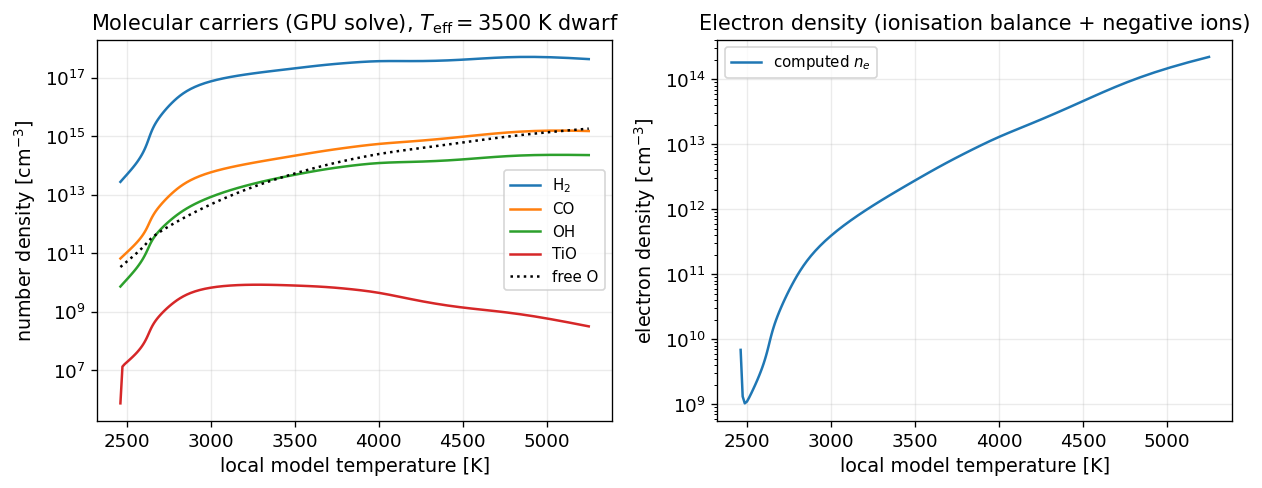

In [18]:
def mol_index(target): return int(np.argmin(np.abs(code_mol[:nummol] - target)))
idx_H2, idx_CO, idx_OH, idx_TiO = mol_index(101.0), mol_index(608.0), mol_index(108.0), mol_index(822.0)
o_eq = int(np.where(idequa[:nequa] == 8)[0][0]); n_O_free = xnz_g[:, o_eq]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2))
ax1.semilogy(T, xnmol_g[:, idx_H2], label="H$_2$")
ax1.semilogy(T, xnmol_g[:, idx_CO], label="CO")
ax1.semilogy(T, xnmol_g[:, idx_OH], label="OH")
ax1.semilogy(T, xnmol_g[:, idx_TiO], label="TiO")
ax1.semilogy(T, n_O_free, "k:", label="free O")
ax1.set_xlabel("local model temperature [K]"); ax1.set_ylabel("number density [cm$^{-3}$]")
ax1.set_title("Molecular carriers (GPU solve), $T_{\\rm eff}=3500$ K dwarf"); ax1.legend(fontsize=9)
ax2.semilogy(T, electron_g, label="computed $n_e$")
ax2.set_xlabel("local model temperature [K]"); ax2.set_ylabel("electron density [cm$^{-3}$]")
ax2.set_title("Electron density (ionisation balance + negative ions)"); ax2.legend(fontsize=9)
fig.tight_layout(); plt.show()

## Part 2 — Molecular continuous opacity

### Why a cool dwarf's continuum is not the Sun's

A warm star's continuum is H$^-$ — bound-free and free-free absorption by the negative hydrogen ion (Lecture 3). That source weakens in a cool dwarf (less ionisation means fewer free electrons to make H$^-$), and molecular sources take over. In the **blue and ultraviolet**, the CH and OH radicals add true **bound-free** continuous absorption — molecular photodissociation, in which a photon energetic enough to break the bond ejects the molecule into unbound fragments (CH$\,+\,h\nu \rightarrow$ C$\,+\,$H). Because the final state is a continuum of relative energies, the cross-section is smooth rather than a forest of lines. In the **near-infrared**, where an M dwarf radiates most of its luminosity, the dominant *molecular* continuum source is **collision-induced absorption by molecular hydrogen** (H$_2$-CIA). A lone H$_2$ is symmetric with no permanent dipole, so its transitions are electric-dipole forbidden; but during a collision (two H$_2$, or H$_2$+He) the transient pair has an **induced dipole** for the femtoseconds of the encounter, and that dipole-allowed channel is the strong absorber. Because two particles must meet, the *volume* coefficient scales as density-squared; expressed as a mass opacity it grows about linearly. We build all three (CHOP, OHOP, H$_2$-CIA) from the atmosphere state and Borysow tables.

**The GPU shape of Part 2.** Unlike Part 1, there is no sequential dependency here — each opacity is a direct table interpolation, independent at every depth and frequency. So the entire continuum is one **fully vectorized, depth-batched `[D, F]` tensor computation**: where the NumPy edition looped over frequency and over depth inside each species function (a double Python loop), the GPU evaluates the whole $[80, 600]$ grid at once. Every band-index bracket, table gather, and bilinear interpolation is a batched tensor op, and the inactive-region cutoffs ($T \ge 9000$ K, energy outside the band, wavenumber $> 20000$ cm$^{-1}$) are branchless `torch.where` masks. This runs fp32 on the GPU at the $\sim10^{-7}$ floor.

### Loading the continuum inputs and the coefficient tables

The continuum needs the atmosphere state (temperature, mass density, the H ground-state and He I populations) plus the molecular-equilibrium populations of CH and OH (`xnfpch`, `xnfpoh` — the mode-1 $N/U$ populations, which in a full run come from the coupled solver of Part 1). The wavelength grid spans 300–5000 nm so we see both the blue CH/OH region and the near-infrared H$_2$-CIA region. The tables are the CH/OH cross-section and partition-function tables and the Borysow H$_2$–H$_2$ / H$_2$–He CIA coefficient tables. The accepted `mol_continuum` port reads them straight from the npz, so we pass the loaded archive through.

In [19]:
mc = np.load(REF / "mol_continuum_inputs.npz")
wl_nm = mc["wavelength_nm"].astype(float)               # nm
freq  = mc["frequency_hz"].astype(float)                # Hz
temp_c = mc["temperature"].astype(float)                # K (same cool dwarf as Part 1)
nlc, nfreq = temp_c.size, freq.size
print(f"continuum grid: {nlc} layers x {nfreq} wavelengths, "
      f"{wl_nm.min():.0f}-{wl_nm.max():.0f} nm, T = {temp_c.min():.0f}-{temp_c.max():.0f} K")
print("tables:", [k for k in mc.files if k.isupper()])

continuum grid: 80 layers x 600 wavelengths, 300-5000 nm, T = 2464-5250 K
tables: ['CH_PARTITION', 'OH_PARTITION', 'CH_CROSSSECT', 'OH_CROSSSECT', 'H2_COLL_H2H2', 'H2_COLL_H2HE']


### The shared physical constants and the device adapters

The port keeps its own constants (matching the Fortran values) and small adapters: `_cpu64` / `_cpu_long` move host arrays onto the working device as fp64/long tensors, `_trunc_i64` is the integer truncation the band-index math needs, and `_finish` moves the final result onto the notebook's device in its working dtype (fp32 on MPS, fp64 on CPU). Transcribed verbatim from the accepted port.

In [20]:
C_LIGHT_CM = 2.99792458e10      # cm/s
H_PLANCK = 6.62607015e-27       # erg s
K_BOLTZ = 1.380649e-16          # erg/K
KBOLTZ_EV_F = 8.6171e-5         # eV/K, the Fortran TKEV constant
LN10 = 2.30258509299405

_CPU = torch.device("cpu"); _F64 = torch.float64

def _np64(inp, name): return np.asarray(inp[name], dtype=np.float64)
def _cpu64(a): return torch.as_tensor(np.ascontiguousarray(a), dtype=_F64, device=_CPU)
def _cpu_long(a): return torch.as_tensor(np.ascontiguousarray(a), dtype=torch.long, device=_CPU)
def _trunc_i64(x): return np.trunc(x).astype(np.int64)

def _finish(x):
    """Move the finished opacity onto the notebook's device in its working dtype."""
    if DEVICE.type == "cpu" and DTYPE is torch.float64:
        return x
    return x.to(device=DEVICE, dtype=DTYPE)

print("continuum constants + device adapters ready")

continuum constants + device adapters ready


### CH and OH continuous opacity (CHOP / OHOP): the frequency-row interpolation

CHOP and OHOP share one structure, so the port factors it into `_band_frequency_rows`: given the whole frequency grid it forms the photon energy in eV, computes the band-energy index branchlessly (`_trunc_i64(ev*10)` with a per-species shift — CH starts at 0.2 eV, OH at 2.1 eV), brackets the cross-section table in energy, and **gathers two adjacent table rows and linearly interpolates** them — `lo + (hi - lo)*frac` — for *every* frequency at once. The inactive region (energy outside the band) is zeroed by a `torch.where` over the `valid` mask, not skipped by a Python `if/return`. This is the loop-over-frequency of the NumPy edition collapsed into one batched gather + interpolation. Transcribed verbatim.

In [21]:
def _band_frequency_rows(freq, cross_table, species):
    """Interpolate the CH/OH cross-section table in PHOTON ENERGY for all frequencies at once."""
    wn = freq / C_LIGHT_CM; ev = wn / 8065.479
    if species == "CH":
        n = _trunc_i64(ev * 10.0); en = n.astype(np.float64) * 0.1
        idx = n - 2; valid = (n >= 20) & (n < 105) & (idx >= 0) & (idx < 104)
    else:  # OH: energy index shifted by 2.0 eV (table starts at 2.1 eV)
        n = _trunc_i64(ev * 10.0) - 20; en = n.astype(np.float64) * 0.1 + 2.0
        idx = n - 1; valid = (n > 0) & (n < 130) & (idx >= 0) & (idx < 129)
    safe_idx = np.clip(idx, 0, cross_table.shape[0] - 2)
    frac = _cpu64((ev - en) / 0.1); table = _cpu64(cross_table); idx_t = _cpu_long(safe_idx)
    lo = table.index_select(0, idx_t); hi = table.index_select(0, idx_t + 1)
    rows = lo + (hi - lo) * frac[:, None]                    # linear interp in energy, all freqs
    valid_t = torch.as_tensor(np.ascontiguousarray(valid), dtype=torch.bool, device=_CPU)
    rows = torch.where(valid_t[:, None], rows, torch.zeros_like(rows))   # branchless band cutoff
    return rows, valid_t, valid_t.to(_F64)

print("_band_frequency_rows ready")

_band_frequency_rows ready


### The depth-batched temperature interpolation and the CH/OH continuum

`_band_continuum` finishes the job: it interpolates the energy-interpolated rows in **temperature** (500 K bins from 2000 K) across all depths, applies the partition function (also $T$-interpolated, by `_partition_per_depth`), converts $\log_{10}(\sigma U)$ with $10^x = e^{x\ln 10}$, and multiplies by the population $n/\rho$ and the stimulated-emission factor — all as `[D, F]` tensor ops with the active-region mask folded in branchlessly. The opacity per gram is $\sigma U \cdot (n_{\rm mol}/\rho)\,(1-e^{-h\nu/kT})$.

In [22]:
def _partition_per_depth(partition, temperature):
    """CH/OH partition function, linear in T (200 K bins from 1000 K), per depth."""
    it = np.clip(_trunc_i64((temperature - 1000.0) / 200.0), 0, 39)
    tn = it.astype(np.float64) * 200.0 + 1000.0
    return partition[it] + (partition[it + 1] - partition[it]) * (temperature - tn) / 200.0

def _cross_temp_cell(temperature):
    """Cross-section T-cell (500 K bins from 2000 K)."""
    it = np.clip(_trunc_i64((temperature - 2000.0) / 500.0), 0, 13)
    tn = it.astype(np.float64) * 500.0 + 2000.0
    return it, (temperature - tn) / 500.0

def _band_continuum(cross, valid_bool, valid_float, it_c, wc, part, active_t, pop, rho, stim):
    """CH/OH continuum on the [D, F] grid: T-interpolate, exponentiate, apply pop/rho and stim."""
    n_t = cross.shape[1]; it0 = it_c.clamp(0, n_t - 2); it1 = it0 + 1
    lo = cross.index_select(1, it0).transpose(0, 1); hi = cross.index_select(1, it1).transpose(0, 1)
    log_x = lo + (hi - lo) * wc[:, None]                     # linear interp in T, all (D,F)
    safe = valid_bool[None, :] & (active_t > 0.0)[:, None]   # branchless active-region mask
    log_x = torch.where(safe, log_x, torch.zeros_like(log_x))
    xsect_u = torch.exp(log_x * LN10) * part[:, None]        # 10^x * U
    return xsect_u * valid_float[None, :] * active_t[:, None] * pop[:, None] / rho[:, None] * stim

print("_band_continuum + temperature-cell helpers ready")

_band_continuum + temperature-cell helpers ready


### The H$_2$ density and the Borysow CIA frequency/temperature interpolation

H$_2$-CIA scales as $n_{\rm H_2}$ times the partner density, so we need $n_{\rm H_2}$ first — from the **same** dissociation polynomial as the code-101 formation constant of Part 1, applied to the H ground-state population: $n_{\rm H_2} = (n_{\rm H,1}\cdot 2\,b_1)^2\,\exp(4.478/kT - 46.4584 + P(T) - \tfrac32\ln T)$, frequency-independent. The Borysow tables give $\log_{10}$ of the absorption coefficient (cm$^5$) on a (wavenumber, temperature) grid; `_h2_frequency_rows` does the **wavenumber** interpolation (250 cm$^{-1}$ bins) for all frequencies at once, masking $> 20000$ cm$^{-1}$ to a $-300$ log floor, and `_temp_lerp_rows` the **temperature** interpolation (1000 K bins). Transcribed verbatim.

In [23]:
def _h2_temp_cell(temperature):
    it = np.clip(_trunc_i64(temperature / 1000.0), 1, 6)
    delt = np.clip((temperature - 1000.0 * it.astype(np.float64)) / 1000.0, 0.0, 1.0)
    return it, delt

def _h2_frequency_rows(freq, h2h2_table, h2he_table):
    """Borysow H2-H2 / H2-He tables interpolated in WAVENUMBER for all frequencies at once."""
    wn = freq / C_LIGHT_CM; nu = np.minimum(79, _trunc_i64(wn / 250.0))
    delnu = (wn - 250.0 * nu.astype(np.float64)) / 250.0
    idx1 = np.clip(np.minimum(nu, 80), 0, 80); idx2 = np.clip(np.minimum(nu + 1, 80), 0, 80)
    valid = wn <= 20000.0                                    # CIA active below 20000 cm^-1
    idx1_t = _cpu_long(idx1); idx2_t = _cpu_long(idx2); delnu_t = _cpu64(delnu)
    h2h2 = _cpu64(h2h2_table); h2he = _cpu64(h2he_table)
    h2h2_rows = h2h2.index_select(0, idx1_t) * delnu_t[:, None] + h2h2.index_select(0, idx2_t) * (1.0 - delnu_t[:, None])
    h2he_rows = h2he.index_select(0, idx1_t) * delnu_t[:, None] + h2he.index_select(0, idx2_t) * (1.0 - delnu_t[:, None])
    valid_t = torch.as_tensor(np.ascontiguousarray(valid), dtype=torch.bool, device=_CPU)
    h2h2_rows = torch.where(valid_t[:, None], h2h2_rows, torch.full_like(h2h2_rows, -300.0))
    h2he_rows = torch.where(valid_t[:, None], h2he_rows, torch.full_like(h2he_rows, -300.0))
    return h2h2_rows, h2he_rows, valid_t, valid_t.to(_F64)

def _temp_lerp_rows(rows_ft, it, delt):
    """Interpolate the (freq, T-node) rows in temperature, per depth."""
    n_t = rows_ft.shape[1]; it_hi = it.clamp(1, n_t - 1); it_lo = it_hi - 1
    lo = rows_ft.index_select(1, it_lo).transpose(0, 1); hi = rows_ft.index_select(1, it_hi).transpose(0, 1)
    return lo * delt[:, None] + hi * (1.0 - delt[:, None])

def _h2_number_density(temperature, xnfph1, bhyd1):
    """H2 number density from the dissociation polynomial (same physics as the code-101 K_f)."""
    tkev = KBOLTZ_EV_F * temperature; tlog = np.log(temperature)
    poly_t = (1.63660e-3 + (-4.93992e-7 + (1.11822e-10 + (-1.49567e-14
              + (1.06206e-18 - 3.08720e-23 * temperature) * temperature) * temperature)
              * temperature) * temperature) * temperature
    exp_term = np.clip(4.478 / tkev - 46.4584 + poly_t - 1.5 * tlog, -100.0, 100.0)
    return (xnfph1 * 2.0 * bhyd1) ** 2 * np.exp(exp_term)

print("H2 density + Borysow interpolation helpers ready")

H2 density + Borysow interpolation helpers ready


### Computing the molecular continuum over the full grid: `mol_continuum`

The driver assembles everything: it interpolates CH/OH in energy and the Borysow tables in wavenumber (all frequencies at once), builds the per-depth temperature cells and the H$_2$ density, forms the stimulated-emission factor, and combines them into the three `[D, F]` opacities. CHOP and OHOP come from `_band_continuum`; H$_2$-CIA is $(10^{X_{\rm H_2He}} n_{\rm He} + 10^{X_{\rm H_2H_2}} n_{\rm H_2})\,n_{\rm H_2}/\rho\,(1-e^{-h\nu/kT})$ — the two-body, density-squared volume coefficient divided by $\rho$. The total is their sum. This is the **entire continuum in one vectorized pass** over the $[80, 600]$ grid, no Python frequency or depth loop. Transcribed verbatim from the accepted port.

In [24]:
def mol_continuum(inp):
    """Molecular continuous opacity (CHOP, OHOP, H2-CIA) on the [D, F] grid, fully vectorized.
    Returns (chop, ohop, h2cia, total)."""
    temperature = _np64(inp, "temperature"); mass_density = _np64(inp, "mass_density")
    xnfph1 = _np64(inp, "xnfph1"); bhyd1 = _np64(inp, "bhyd1"); xnfhe1 = _np64(inp, "xnfhe1")
    xnfpch = _np64(inp, "xnfpch"); xnfpoh = _np64(inp, "xnfpoh"); freq = _np64(inp, "frequency_hz")
    ch_partition = _np64(inp, "CH_PARTITION"); oh_partition = _np64(inp, "OH_PARTITION")
    ch_crosssect = _np64(inp, "CH_CROSSSECT"); oh_crosssect = _np64(inp, "OH_CROSSSECT")
    h2h2_table = _np64(inp, "H2_COLL_H2H2"); h2he_table = _np64(inp, "H2_COLL_H2HE")

    # frequency-row interpolations (all freqs at once)
    ch_cross, ch_valid_bool, ch_valid = _band_frequency_rows(freq, ch_crosssect, "CH")
    oh_cross, oh_valid_bool, oh_valid = _band_frequency_rows(freq, oh_crosssect, "OH")
    h2h2_nu, h2he_nu, h2_valid_bool, h2_valid = _h2_frequency_rows(freq, h2h2_table, h2he_table)

    # per-depth cells, partitions, H2 density
    ch_part = _partition_per_depth(ch_partition, temperature); oh_part = _partition_per_depth(oh_partition, temperature)
    it_c, wc = _cross_temp_cell(temperature); it_h2, delt = _h2_temp_cell(temperature)
    xnh2 = _h2_number_density(temperature, xnfph1, bhyd1)

    temp_t = _cpu64(temperature); rho_t = _cpu64(mass_density); xnfhe1_t = _cpu64(xnfhe1)
    xnfpch_t = _cpu64(xnfpch); xnfpoh_t = _cpu64(xnfpoh); xnh2_t = _cpu64(xnh2)
    ch_part_t = _cpu64(ch_part); oh_part_t = _cpu64(oh_part); wc_t = _cpu64(wc); delt_t = _cpu64(delt)
    active_t = _cpu64((temperature < 9000.0).astype(np.float64))     # branchless T-cutoff
    it_c_t = _cpu_long(it_c); it_h2_t = _cpu_long(it_h2)

    freq_arg_t = _cpu64(H_PLANCK * freq / K_BOLTZ)
    stim = 1.0 - torch.exp(-freq_arg_t[None, :] / temp_t[:, None])   # stimulated emission [D,F]

    chop64 = _band_continuum(ch_cross, ch_valid_bool, ch_valid, it_c_t, wc_t, ch_part_t,
                             active_t, xnfpch_t, rho_t, stim)
    ohop64 = _band_continuum(oh_cross, oh_valid_bool, oh_valid, it_c_t, wc_t, oh_part_t,
                             active_t, xnfpoh_t, rho_t, stim)

    xh2h2 = _temp_lerp_rows(h2h2_nu, it_h2_t, delt_t); xh2he = _temp_lerp_rows(h2he_nu, it_h2_t, delt_t)
    xh2h2 = torch.where(h2_valid_bool[None, :], xh2h2, torch.full_like(xh2h2, -300.0))
    xh2he = torch.where(h2_valid_bool[None, :], xh2he, torch.full_like(xh2he, -300.0))
    ten = torch.tensor(10.0, dtype=_F64, device=_CPU)
    h2cia64 = ((torch.pow(ten, xh2he) * xnfhe1_t[:, None] + torch.pow(ten, xh2h2) * xnh2_t[:, None])
               * xnh2_t[:, None] / rho_t[:, None] * stim * h2_valid[None, :])
    total64 = chop64 + ohop64 + h2cia64
    return _finish(chop64), _finish(ohop64), _finish(h2cia64), _finish(total64)

t0 = time.time()
chop, ohop, h2cia, total = mol_continuum(mc)
print(f"molecular continuum computed over the {nlc}x{nfreq} grid in {time.time()-t0:.3f}s "
      f"(device {DEVICE.type})")

molecular continuum computed over the 80x600 grid in 0.023s (device mps)


### Benchmark: the GPU continuum against the NumPy twin

We validate the torch `mol_continuum` against the inline NumPy twin (the scalar reference from `verify_mol_continuum.py` — CHOP/OHOP/H2COLLOP with their Python frequency loops — the parity oracle) and against the shipped ground truth, reporting `max|rel|` on chop, ohop, h2cia, and the total. First the scalar NumPy twin.

In [25]:
# --- the NumPy twin: scalar CHOP/OHOP/H2COLLOP, the parity oracle ---
temp_np = mc["temperature"].astype(float); rho_np = mc["mass_density"].astype(float)
xnfph1_np = mc["xnfph1"].astype(float); bhyd1_np = mc["bhyd1"].astype(float)
xnfhe1_np = mc["xnfhe1"].astype(float); xnfpch_np = mc["xnfpch"].astype(float)
xnfpoh_np = mc["xnfpoh"].astype(float)
CH_PARTITION = mc["CH_PARTITION"]; OH_PARTITION = mc["OH_PARTITION"]
CH_CROSSSECT = mc["CH_CROSSSECT"]; OH_CROSSSECT = mc["OH_CROSSSECT"]
H2H2 = mc["H2_COLL_H2H2"]; H2HE = mc["H2_COLL_H2HE"]
tkev_np = KBOLTZ_EV_F * temp_np; tlog_np = np.log(temp_np)
stim_np = 1.0 - np.exp(-H_PLANCK * freq[None, :] / (K_BOLTZ * temp_np[:, None]))
_poly_t = (1.63660e-3 + (-4.93992e-7 + (1.11822e-10 + (-1.49567e-14
           + (1.06206e-18 - 3.08720e-23 * temp_np) * temp_np) * temp_np) * temp_np) * temp_np) * temp_np
XNH2_np = (xnfph1_np * 2.0 * bhyd1_np) ** 2 * np.exp(np.clip(4.478 / tkev_np - 46.4584 + _poly_t - 1.5 * tlog_np, -100, 100))

def _band_xsect_np(freq_scalar, CROSS, PART, n_off, idx_off, en_off, n_lo, n_hi, idx_hi):
    out = np.zeros(temp_np.size); wn = freq_scalar / C_LIGHT_CM; ev = wn / 8065.479
    n = int(ev * 10) - n_off
    if n <= n_lo or n >= n_hi: return out
    en = n * 0.1 + en_off; idx = n - idx_off
    if idx < 0 or idx >= idx_hi: return out
    cross = CROSS[idx] + (CROSS[idx + 1] - CROSS[idx]) * (ev - en) / 0.1
    for j in range(temp_np.size):
        tj = temp_np[j]
        if tj >= 9000.0: continue
        it_p = max(0, min(int((tj - 1000.0) / 200.0), 39)); tn_p = it_p * 200.0 + 1000.0
        part = PART[it_p] + (PART[it_p + 1] - PART[it_p]) * (tj - tn_p) / 200.0
        it_c = max(0, min(int((tj - 2000.0) / 500.0), 13)); tn_c = it_c * 500.0 + 2000.0
        log_x = cross[it_c] + (cross[it_c + 1] - cross[it_c]) * (tj - tn_c) / 500.0
        out[j] = np.exp(log_x * LN10) * part
    return out

def h2cia_np(freq_scalar, stim_col):
    out = np.zeros(temp_np.size); wn = freq_scalar / C_LIGHT_CM
    if wn > 20000.0: return out
    nu = min(79, int(wn / 250.0)); delnu = (wn - 250.0 * nu) / 250.0
    idx1 = min(nu, 80); idx2 = min(nu + 1, 80)
    h2h2_nu = H2H2[idx1] * delnu + H2H2[idx2] * (1.0 - delnu)
    h2he_nu = H2HE[idx1] * delnu + H2HE[idx2] * (1.0 - delnu)
    for j in range(temp_np.size):
        tj = temp_np[j]; it = max(1, min(6, int(tj / 1000.0)))
        delt = max(0.0, min(1.0, (tj - 1000.0 * it) / 1000.0))
        xh2h2 = h2h2_nu[it - 1] * delt + h2h2_nu[it] * (1.0 - delt)
        xh2he = h2he_nu[it - 1] * delt + h2he_nu[it] * (1.0 - delt)
        out[j] = (10.0 ** xh2he * xnfhe1_np[j] + 10.0 ** xh2h2 * XNH2_np[j]) * XNH2_np[j] / rho_np[j] * stim_col[j]
    return out

print("NumPy twin: scalar CHOP/OHOP/H2COLLOP ready")

NumPy twin: scalar CHOP/OHOP/H2COLLOP ready


In [26]:
chop_ref = np.zeros((nlc, nfreq)); ohop_ref = np.zeros((nlc, nfreq)); h2cia_ref = np.zeros((nlc, nfreq))
for j in range(nfreq):
    f = freq[j]; stim_j = stim_np[:, j]
    chop_ref[:, j] = _band_xsect_np(f, CH_CROSSSECT, CH_PARTITION, 0, 2, 0.0, 19, 105, 104) * xnfpch_np / rho_np * stim_j
    ohop_ref[:, j] = _band_xsect_np(f, OH_CROSSSECT, OH_PARTITION, 20, 1, 2.0, 0, 130, 129) * xnfpoh_np / rho_np * stim_j
    h2cia_ref[:, j] = h2cia_np(f, stim_j)
total_ref = chop_ref + ohop_ref + h2cia_ref

# COMPARISON ONLY: pykurucz ground truth, never used in the computation
truth = np.load(REF / "mol_continuum_truth.npz")
print("GPU torch mol_continuum  vs  inline NumPy twin:")
compare("CHOP   (CH)     ", chop, chop_ref, tol=1e-6, floor=0.0)
compare("OHOP   (OH)     ", ohop, ohop_ref, tol=1e-6, floor=0.0)
compare("H2-CIA (Borysow)", h2cia, h2cia_ref, tol=1e-6, floor=0.0)
compare("MOL TOTAL       ", total, total_ref, tol=1e-6, floor=0.0)
print("\nGPU torch mol_continuum  vs  pykurucz ground truth:")
rc = compare("CHOP   (CH)     ", chop, truth["chop"], tol=1e-6, floor=0.0)
ro = compare("OHOP   (OH)     ", ohop, truth["ohop"], tol=1e-6, floor=0.0)
rh = compare("H2-CIA (Borysow)", h2cia, truth["h2cia"], tol=1e-6, floor=0.0)
rt = compare("MOL TOTAL       ", total, truth["mol_total"], tol=1e-6, floor=0.0)
is_fp32 = (DTYPE == torch.float32)
floor_c = 1e-6 if is_fp32 else 1e-10
worst_c = max(rc, ro, rh, rt)
print(f"\nmolecular continuum max relative error = {worst_c:.3e}   floor = {floor_c:.0e}   ->",
      "[PASS]" if worst_c < floor_c else "[CHECK]")
assert worst_c < floor_c, f"continuum deviates by {worst_c:.2e}, above the float floor {floor_c:.0e}"

GPU torch mol_continuum  vs  inline NumPy twin:


CHOP   (CH)                   max|rel diff| = 5.85e-08   [agree]   (n=3280)
OHOP   (OH)                   max|rel diff| = 5.87e-08   [agree]   (n=3040)
H2-CIA (Borysow)              max|rel diff| = 5.94e-08   [agree]   (n=45920)


MOL TOTAL                     max|rel diff| = 5.94e-08   [agree]   (n=48000)

GPU torch mol_continuum  vs  pykurucz ground truth:
CHOP   (CH)                   max|rel diff| = 5.85e-08   [agree]   (n=3280)
OHOP   (OH)                   max|rel diff| = 5.87e-08   [agree]   (n=3040)
H2-CIA (Borysow)              max|rel diff| = 5.94e-08   [agree]   (n=45920)
MOL TOTAL                     max|rel diff| = 5.94e-08   [agree]   (n=48000)

molecular continuum max relative error = 5.941e-08   floor = 1e-06   -> [PASS]


**What the number means.** The GPU `mol_continuum` matches both the NumPy twin and pykurucz to $\sim6\times10^{-8}$ (fp32 on MPS) — single-precision round-off of the table interpolation and the exponentiation, *not* a physics difference. On a CPU/fp64 run it is bit-exact, as the NumPy edition is. The branchless `torch.where` band cutoffs select the same active region as the scalar `if/return`, the flat-gather table reads reproduce the same bilinear interpolation, and the whole $[80, 600]$ grid is evaluated in one vectorized pass where the NumPy edition ran a double Python loop over frequency and depth.

### H$_2$-CIA is the cool-star near-infrared continuum

The physical payoff. At a representative cool photospheric layer ($T\approx3000$ K), the three species at four wavelengths from blue to near-infrared: CH and OH carry the blue *molecular* continuum, but from about 1 $\mu$m outward they switch off entirely and H$_2$-CIA is the **whole** molecular continuum — overlapping a large fraction of the near-infrared flux an M dwarf emits.

In [27]:
chop_g = chop.detach().cpu().double().numpy(); ohop_g = ohop.detach().cpu().double().numpy()
h2cia_g = h2cia.detach().cpu().double().numpy(); total_g = total.detach().cpu().double().numpy()

jcool = int(np.argmin(np.abs(temp_c - 3000.0)))     # a cool photospheric layer
print(f"H2-CIA dominance at T = {temp_c[jcool]:.0f} K:")
for target in (450.0, 1000.0, 1500.0, 2200.0):       # blue -> near-IR
    i = int(np.argmin(np.abs(wl_nm - target))); tot = total_g[jcool, i]
    frac = (h2cia_g[jcool, i] / tot * 100.0) if tot > 0 else 0.0
    print(f"  {wl_nm[i]:6.0f} nm : CHOP={chop_g[jcool,i]:.3e} OHOP={ohop_g[jcool,i]:.3e} "
          f"H2CIA={h2cia_g[jcool,i]:.3e}  ->  H2-CIA = {frac:5.1f}% of mol continuum")

H2-CIA dominance at T = 3001 K:
     449 nm : CHOP=1.118e-08 OHOP=1.484e-07 H2CIA=0.000e+00  ->  H2-CIA =   0.0% of mol continuum
     998 nm : CHOP=0.000e+00 OHOP=0.000e+00 H2CIA=1.290e-06  ->  H2-CIA = 100.0% of mol continuum
    1501 nm : CHOP=0.000e+00 OHOP=0.000e+00 H2CIA=2.538e-05  ->  H2-CIA = 100.0% of mol continuum
    2199 nm : CHOP=0.000e+00 OHOP=0.000e+00 H2CIA=1.724e-04  ->  H2-CIA = 100.0% of mol continuum


The molecular continuum across the whole grid at the deepest layer of the cool-dwarf model ($T\approx5250$ K — a *local* layer temperature, the warmest, densest base of the $T_{\rm eff}=3500$ K photosphere, where the density-squared H$_2$-CIA is largest). CH and OH appear as blue/near-UV bumps; H$_2$-CIA switches on at its $20000$ cm$^{-1}$ ($\approx500$ nm) threshold and dominates through the near-infrared.

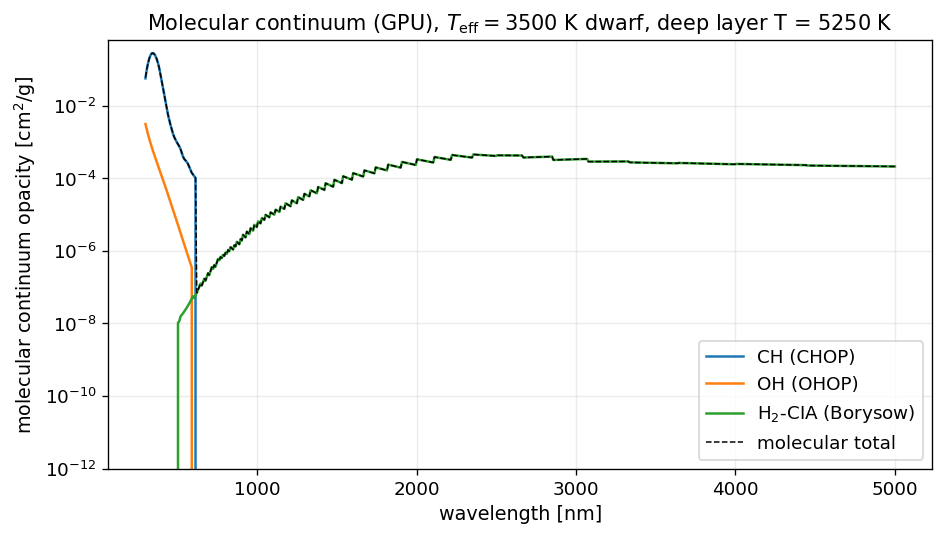

In [28]:
jdeep = nlc - 1
fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.plot(wl_nm, chop_g[jdeep], label="CH (CHOP)")
ax.plot(wl_nm, ohop_g[jdeep], label="OH (OHOP)")
ax.plot(wl_nm, h2cia_g[jdeep], label="H$_2$-CIA (Borysow)")
ax.plot(wl_nm, total_g[jdeep], "k--", lw=0.9, label="molecular total")
ax.set_yscale("log"); ax.set_xlabel("wavelength [nm]")
ax.set_ylabel("molecular continuum opacity [cm$^2$/g]")
ax.set_title(f"Molecular continuum (GPU), $T_{{\\rm eff}}=3500$ K dwarf, deep layer T = {temp_c[jdeep]:.0f} K")
ax.set_ylim(1e-12, None); ax.legend()
fig.tight_layout(); plt.show()

## Synthesis

The two halves of this lecture are the two pieces Lecture 12 took on credit, now paid in full — and rebuilt the GPU way.

**The chemistry is coupled, and we vectorized exactly the right part of it.** A single formation constant $K_f(T)$ gives one molecule's density *if* you already know the free-atom densities — but you do not, because every element is shared among competing molecules and $n_e$ feeds back through negative ions. The honest object is the coupled system: total-particle conservation, one number-conservation equation per element, charge balance, every molecule's mass-action term. We solved it the production way — Newton–Raphson with damping — but recast the solver into its GPU form: the **inner Newton iteration** became dense tensor algebra, with an **autodiff `jacrev` Jacobian** replacing the hand-coded `DEQ`, a **branchless log-space residual** built from a precomputed incidence structure, and a **column-scaled `torch.linalg.solve`** conditioning the $\sim$25-dex Jacobian in one LAPACK call instead of SOLVIT's scalar elimination loop. The **depth loop stayed a loop**, because depth $j$ is warm-started from the converged depth $j-1$ — a true sequential dependency that a cold-started batch solve would diverge on. That division — *vectorize what is independent, loop over what is sequential* — is the lecture's central GPU lesson, and we were honest about the precision: the stiff solve runs in **fp64 on CPU**, the reference path, where the autodiff Newton reaches the same equilibrium as the Fortran DEQ+SOLVIT to a $\sim10^{-13}$ float64 floor.

**The continuum is molecular, and fully vectorizes.** A cool dwarf's continuum is not the Sun's H$^-$. CH and OH add bound-free photodissociation absorption in the blue; H$_2$ collision-induced absorption — a transient supermolecule with an induced dipole — dominates the *molecular* near-infrared continuum from 1 to 2.2 $\mu$m. With no sequential dependency, the entire continuum is one fully vectorized depth-batched `[80, 600]` tensor computation: every band-index bracket, table gather, and bilinear interpolation a batched op, every inactive-region cutoff a branchless `torch.where`. It runs fp32 on the GPU and matches the NumPy twin to $\sim6\times10^{-8}$.

With these in hand, nothing in a cool-star synthesis is borrowed. **Lecture 14** assembles every component built so far — the equation of state, the continuum, the atomic and hydrogen and helium lines, these molecular bands and continuum, and the JOSH transfer — into one lean GPU synthesiser and runs the **emergent spectrum end to end** across stars spanning the HR diagram.

## Summary

- **Molecular chemistry is a coupled problem.** Elements are shared among competing molecules and negative ions tie the chemistry to $n_e$, so a per-molecule $K_f$ is an *input*, not the answer: one **total-particle** equation, one **number-conservation** equation per element, one **charge-balance** equation, every molecule depositing its mass-action term $n_{\rm mol}=K_f\prod_i n_i$.
- **The Newton iteration vectorizes; the depth loop does not.** At one depth the step is an **autodiff (`jacrev`) Jacobian** + a **column-scaled `torch.linalg.solve`** over the $n_{\rm equa}$ unknowns, with the residual built **branchlessly in log space** from a precomputed incidence structure (`MolStructure`). The depth loop **stays a loop** — depth $j$ is warm-started from converged depth $j-1$, a sequential dependency a cold batch solve would diverge on.
- **Autodiff replaces the hand-coded Jacobian.** `jacrev` differentiates the residual itself, so the Jacobian can never drift out of sync with the model; column scaling conditions the $\sim$25-dex Jacobian, the linear-algebra equivalent of SOLVIT's complete pivoting, in one LAPACK call.
- **Precision honesty.** The stiff coupled solve runs in **fp64 on CPU** (the reference path); it reaches the same equilibrium as the production Fortran DEQ+SOLVIT to a $\sim10^{-13}$ float64 non-associativity floor, with $K_f(T)$ **bit-exact**.
- **The molecular continuum fully vectorizes.** **CH** (CHOP) and **OH** (OHOP) photodissociation and **H$_2$-CIA** (Borysow) are one depth-batched `[80, 600]` table interpolation, all cutoffs branchless; it runs fp32 on the GPU and matches the twin to $\sim6\times10^{-8}$.
- **H$_2$-CIA dominates the molecular continuum from 1 to 2.2 $\mu$m**, overlapping much of the M dwarf's emergent flux — a two-body induced-dipole process whose *volume* coefficient goes as density-squared (the mass opacity, $\div\rho$, rises only about linearly).

## Practice exercises

**1. Who owns the oxygen?** Using the GPU-converged `xnz_g` and `xnmol_g`, sum the oxygen nuclei locked in each O-bearing molecule (CO, OH, TiO, ...) plus free O, and confirm the total equals the oxygen abundance times $n_0$. Which molecule carries the most oxygen at 3000 K, and why? (Hint: compare $D_0$.)

**2. The depth loop really is sequential.** Modify `_nmolec_driver` to **cold-seed every depth** (use the $j=0$ seed at all depths instead of the warm-start `xn_prev_conv * ratio`). Watch the deep, stiff layers take far more iterations — or fail to converge in 200 — and time the slowdown. This is the experiment that justifies keeping the depth loop: the warm-start chain is load-bearing.

**3. Autodiff vs hand-DEQ.** Pick one depth and one iteration. Print the `jacrev` Jacobian `J` and the NumPy twin's hand-coded `DEQ` for the same state. Confirm they agree to fp64 round-off — the autodiff Jacobian *is* the analytic one, derived from the residual for free.

**4. Column scaling matters.** In `_newton_step`, drop the column scaling (solve `J @ d = eq` directly) and re-run the solve. Watch the residual stall or the populations degrade at the depths where the Jacobian's dynamic range is widest. Explain why scaling by $|x_n|$ is the linear-algebra equivalent of SOLVIT's complete pivoting.

**5. The induced-dipole scaling.** Take two depths differing in density by $\sim10\times$ and confirm the H$_2$-CIA *volume* coefficient ratio (multiply the mass opacity by $\rho$) is close to the *square* of the density ratio, while the mass opacity itself rises only about linearly. Contrast with a one-body process.

**6. Where H$_2$-CIA takes over.** From `chop_g`/`ohop_g`/`h2cia_g` at the cool layer, find the wavelength where H$_2$-CIA overtakes CH+OH, and explain why it falls near 1 $\mu$m for an M dwarf (Planck peak, CH/OH band edges, the CIA onset at the $20000$ cm$^{-1}$ threshold).

## Further reading

- **Russell, H. N. (1934). *Astrophys. J.* 79, 317.** "Molecules in the Sun and Stars" — the classic application of the law of mass action to the molecular composition of stellar atmospheres.
- **Tatum, J. B. (1966). *Publ. Dom. Astrophys. Obs.* 13, 1.** The molecular partition-function and equilibrium-constant formalism underlying the $\log K(T)$ polynomial fits used here.
- **Borysow, A., Jorgensen, U. G. & Zheng, C. (1997). *Astron. Astrophys.* 324, 185.** Collision-induced absorption of H$_2$–H$_2$ — the source of the H$_2$-CIA tables and the near-infrared continuum of cool dwarfs.
- **Tsuji, T. (1973). *Astron. Astrophys.* 23, 411.** Molecular abundances in cool stellar atmospheres — the coupled-equilibrium treatment and the C/O dividing line between M and C stars.
- **Kurucz, R. L. (1970). *SAO Special Report* 309 (ATLAS).** The NMOLEC molecular-equilibrium routine, the SOLVIT linear solver, and the CHOP/OHOP/H2COLLOP continuous-opacity functions reproduced here.
- **Griewank, A. & Walther, A. (2008). *Evaluating Derivatives: Principles and Techniques of Algorithmic Differentiation*, 2nd ed., SIAM.** The reverse-mode automatic differentiation (`jacrev`) that produces the Newton Jacobian here from the residual itself.
- **Kim, E. M. & Ting, Y.-S. (2026). [*pykurucz*](https://arxiv.org/abs/2603.11693).** The implementation our reference populations and molecular continuum are computed with.